In [1]:
from langgraph.graph import StateGraph,START,END
from typing_extensions import TypedDict

In [20]:
class BMIstate(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    bmi_category:str


In [21]:
def bmi_cal(state:BMIstate)->BMIstate:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    state['bmi'] = round(bmi,2)
    return state

In [25]:
def compare_bmi(state:BMIstate)->BMIstate:
    bmi = state['bmi']
    if bmi > 30:
        state['bmi_category']='obese'
    elif bmi <30:
        state['bmi_category']='ok-fit'
    elif bmi > 20:
        state['bmi_category']='fit'
    elif bmi > 10:
        state['bmi_category']='underweight'

    return state

In [27]:
#define your graph
workflow = StateGraph(BMIstate)

#define your nodes
workflow.add_node('bmi_cal',bmi_cal)
workflow.add_node('bmi_category',compare_bmi)

#connect edges
workflow.add_edge(START,'bmi_cal')
workflow.add_edge('bmi_cal','bmi_category')
workflow.add_edge('bmi_category',END)

#compile graph
chain = workflow.compile()


In [28]:
intial_state = {'weight_kg':80,'height_m':1.75}
final_state = chain.invoke(intial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.75, 'bmi': 26.12, 'bmi_category': 'ok-fit'}


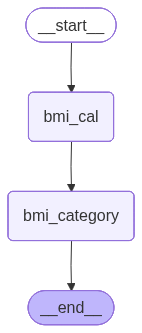

In [29]:
from IPython.display import Image
Image(chain.get_graph().draw_mermaid_png())